# Receptor Interaction Analysis

This notebook reproduces the receptor knockdown × ligand microenvironment interaction analysis
from the Perturb-Tags spatial multiome data.

## Overview
For each of 8 receptor KD targets, we:
1. Compute a local ligand microenvironment score for each cell using a Gaussian kernel
2. Fit an OLS interaction model: `expression ~ β_KD + β_ligand + β_KD×ligand`
3. Sweep across radii (25-500 µm) to find optimal interaction distances
4. Run the analysis for RNA genes, ATAC peaks, and TE families


In [1]:
# Dependencies are installed in the execution environment before running this notebook.
print("Required Python dependencies are available.")

Required Python dependencies are available.


In [2]:
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = 'data'
OUTPUT_DIR = 'output'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

DRIVE_IDS = {
    'CATATAC': '1NZzzEX9zHSj5Cp5ewuHRataW0jkIA-bo',
    'TE_RNA': '1PU3dJ0n3siOUqt67knTc3mXWe1k1gROV',
    'TE_ATAC': '1H_7eV_ZynrXNHy0P9YAb66aTWLA9fvIg',
}

CATATAC_PATH = os.path.join(DATA_DIR, 'all_lanes_CATATAC.h5mu')
TE_RNA_PATH = os.path.join(DATA_DIR, 'aggregated_TE_RNA.h5ad')
TE_ATAC_PATH = os.path.join(DATA_DIR, 'aggregated_TE_ATAC.h5ad')

RECEPTOR_LIGANDS = {
    'FZD3': ['WNT1', 'WNT2', 'WNT2B', 'WNT3', 'WNT3A', 'WNT4', 'WNT5A', 'WNT5B', 'WNT6',
             'WNT7A', 'WNT7B', 'WNT8A', 'WNT8B', 'WNT9A', 'WNT9B', 'WNT10A', 'WNT10B', 'WNT11', 'WNT16'],
    'LGR4': ['RSPO1', 'RSPO2', 'RSPO3', 'RSPO4'],
    'PDGFRA': ['PDGFA', 'PDGFB', 'PDGFC', 'PDGFD'],
    'NRP1': ['SEMA3A', 'SEMA3B', 'SEMA3C', 'SEMA3D', 'SEMA3E', 'SEMA3F', 'SEMA3G',
             'VEGFA', 'VEGFB', 'PGF', 'SEMA6D'],
    'PLXNA2': ['SEMA3A', 'SEMA3B', 'SEMA3C', 'SEMA3D', 'SEMA3F', 'SEMA5A', 'SEMA6A', 'SEMA6B', 'SEMA6D'],
    'EPHA7': ['EFNA1', 'EFNA2', 'EFNA3', 'EFNA4', 'EFNA5'],
    'NOTCH1': ['DLL1', 'DLL3', 'DLL4', 'JAG1', 'JAG2'],
    'ACVR2B': ['BMP2', 'BMP4', 'BMP5', 'BMP6', 'BMP7', 'GDF5', 'GDF11', 'INHBA', 'INHBB', 'NODAL', 'MSTN'],
}

ALL_RADII = [25, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
RECEPTORS_ORDER = ['LGR4', 'NOTCH1', 'FZD3', 'NRP1', 'ACVR2B', 'EPHA7', 'PLXNA2', 'PDGFRA']


## 1. Download data

In [3]:
required_files = {
    'CATATAC': CATATAC_PATH,
    'TE_RNA': TE_RNA_PATH,
    'TE_ATAC': TE_ATAC_PATH,
}
missing = [f"{name}: {path}" for name, path in required_files.items() if not os.path.isfile(path)]
if missing:
    raise FileNotFoundError("Required local data file(s) missing:\n" + "\n".join(missing))
for name, path in required_files.items():
    print(f"{name} exists at {path}")

CATATAC exists at data/all_lanes_CATATAC.h5mu
TE_RNA exists at data/aggregated_TE_RNA.h5ad
TE_ATAC exists at data/aggregated_TE_ATAC.h5ad


## 2. Load data

In [4]:
def read_categorical(grp):
    if isinstance(grp, h5py.Dataset):
        vals = grp[:]
        return np.array([v.decode() if isinstance(v, bytes) else v for v in vals])
    cats = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['categories'][:]])
    codes = grp['codes'][:]
    return cats[codes]

def read_nullable_string(grp):
    if isinstance(grp, h5py.Dataset):
        vals = grp[:]
        return np.array([v.decode() if isinstance(v, bytes) else v for v in vals])
    vals = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['values'][:]])
    if 'mask' in grp:
        mask = grp['mask'][:]
        vals[mask] = ''
    return vals

def read_sparse_matrix(grp):
    from scipy.sparse import csr_matrix, csc_matrix
    data = grp['data'][:]
    indices = grp['indices'][:]
    indptr = grp['indptr'][:]
    if 'shape' in grp.attrs:
        shape = tuple(grp.attrs['shape'])
    else:
        shape = (len(indptr) - 1, indices.max() + 1 if len(indices) > 0 else 0)
    encoding = grp.attrs.get('encoding-type', b'csr_matrix')
    if isinstance(encoding, bytes): encoding = encoding.decode()
    if 'csc' in encoding:
        return csc_matrix((data, indices, indptr), shape=shape)
    return csr_matrix((data, indices, indptr), shape=shape)

print("Loading CATATAC multiome data...")
with h5py.File(CATATAC_PATH, 'r') as f:
    target_calls = read_categorical(f['obs']['target_call'])
    lanes = read_categorical(f['obs']['lane'])
    sp1 = f['obs']['SPATIAL_1']
    sp2 = f['obs']['SPATIAL_2']
    if isinstance(sp1, h5py.Group) and 'categories' in sp1:
        spatial_1 = read_categorical(sp1).astype(float)
        spatial_2 = read_categorical(sp2).astype(float)
    else:
        spatial_1 = np.array(sp1[:], dtype=float)
        spatial_2 = np.array(sp2[:], dtype=float)
    spatial_coords = np.column_stack([spatial_1, spatial_2])
    gex_barcodes = read_categorical(f['obs']['gex_barcode'])
    rna_X = read_sparse_matrix(f['mod']['rna']['X'])
    rna_genes = read_categorical(f['mod']['rna']['var']['_index'])
    atac_X = read_sparse_matrix(f['mod']['atac']['X'])
    atac_peaks = read_nullable_string(f['mod']['atac']['var']['peak_id'])

n_cells = len(target_calls)
gene_to_idx = {g: i for i, g in enumerate(rna_genes)}
print(f"Loaded {n_cells} cells, {len(rna_genes)} genes, {len(atac_peaks)} peaks")

print("Loading TE data...")
with h5py.File(TE_RNA_PATH, 'r') as f:
    te_rna_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_rna_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_rna_X = read_sparse_matrix(f['X'])
    te_rna_names = read_categorical(f['var']['_index'])

with h5py.File(TE_ATAC_PATH, 'r') as f:
    te_atac_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_atac_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_atac_X = read_sparse_matrix(f['X'])
    if '_index' in f['var']:
        te_atac_names = read_categorical(f['var']['_index'])
    elif 'TE_family' in f['var']:
        te_atac_names = read_categorical(f['var']['TE_family'])
    else:
        te_atac_names = np.array([f'TE_{i}' for i in range(te_atac_X.shape[1])])

catatac_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(lanes, gex_barcodes)])
te_rna_key_to_idx = {f"{l}_{b}": i for i, (l, b) in enumerate(zip(te_rna_lanes, te_rna_barcodes))}
te_atac_key_to_idx = {f"{l}_{b}": i for i, (l, b) in enumerate(zip(te_atac_lanes, te_atac_barcodes))}
te_rna_idx_map = np.array([te_rna_key_to_idx.get(k, -1) for k in catatac_keys])
te_atac_idx_map = np.array([te_atac_key_to_idx.get(k, -1) for k in catatac_keys])
print(f"TE RNA: {te_rna_X.shape}, TE ATAC: {te_atac_X.shape}")


Loading CATATAC multiome data...


Loaded 17043 cells, 29562 genes, 142529 peaks
Loading TE data...


TE RNA: (17043, 1340), TE ATAC: (42680, 1391)


## 3. Interaction regression functions

In [5]:
def compute_ligand_score(cell_indices, spatial_coords, rna_X, gene_to_idx, 
                         ligand_genes, radius, lanes, lane_values,
                         exclude_kd_indices=None):
    """Compute Gaussian-weighted ligand score for each cell.

    For each cell, find neighbors within radius in the same lane (EB).
    Weight neighbors by Gaussian kernel: w(d) = exp(-d^2 / (2*sigma^2))
    where sigma = radius / sqrt(-2*log(0.001)).
    Compute weighted mean of total ligand expression across neighbors.
    """
    sigma = radius / np.sqrt(-2 * np.log(0.001))

    ligand_idxs = [gene_to_idx[g] for g in ligand_genes if g in gene_to_idx]
    if not ligand_idxs:
        return np.zeros(len(cell_indices))

    ligand_expr = np.array(rna_X[:, ligand_idxs].sum(axis=1)).ravel()
    scores = np.zeros(len(cell_indices))
    exclude_set = set(exclude_kd_indices) if exclude_kd_indices is not None else set()

    for lane in lane_values:
        lane_mask = lanes == lane
        lane_cell_idxs = np.where(lane_mask)[0]
        lane_coords = spatial_coords[lane_cell_idxs]
        tree = KDTree(lane_coords)
        lane_set = set(lane_cell_idxs)

        for i, cell_idx in enumerate(cell_indices):
            if cell_idx not in lane_set:
                continue
            cell_pos = np.searchsorted(lane_cell_idxs, cell_idx)
            if cell_pos >= len(lane_cell_idxs) or lane_cell_idxs[cell_pos] != cell_idx:
                continue
            neighbor_positions = tree.query_ball_point(lane_coords[cell_pos], radius)
            neighbor_global = [lane_cell_idxs[p] for p in neighbor_positions 
                             if lane_cell_idxs[p] != cell_idx and lane_cell_idxs[p] not in exclude_set]
            if not neighbor_global:
                continue
            dists = np.linalg.norm(spatial_coords[neighbor_global] - spatial_coords[cell_idx], axis=1)
            weights = np.exp(-dists**2 / (2 * sigma**2))
            weights /= weights.sum()
            scores[i] = np.dot(weights, ligand_expr[neighbor_global])

    return scores


def run_interaction_regression(kd_indices, ctrl_indices, ligand_scores_kd, ligand_scores_ctrl,
                               expression_matrix, feature_names, min_det=0.05):
    """Run vectorized OLS: expression ~ KD + ligand + KD*ligand for all features at once."""
    from statsmodels.stats.multitest import multipletests
    from scipy.sparse import issparse

    all_indices = np.concatenate([kd_indices, ctrl_indices])
    n_kd = len(kd_indices)
    kd_var = np.concatenate([np.ones(n_kd), np.zeros(len(ctrl_indices))])
    all_ligand = np.concatenate([ligand_scores_kd, ligand_scores_ctrl])
    if all_ligand.std() == 0:
        return pd.DataFrame()
    all_ligand_z = (all_ligand - all_ligand.mean()) / all_ligand.std()
    interaction = kd_var * all_ligand_z

    # Design matrix: [const, kd, ligand, interaction]
    X = np.column_stack([np.ones(len(all_indices)), kd_var, all_ligand_z, interaction])
    n = len(all_indices)
    p = X.shape[1]

    # Get expression submatrix
    if issparse(expression_matrix):
        Y = expression_matrix[all_indices].toarray()
    else:
        Y = expression_matrix[all_indices]

    # Detection filter
    det = (Y != 0).mean(axis=0)
    det_mask = det > min_det
    feat_indices = np.where(det_mask)[0]
    if len(feat_indices) == 0:
        return pd.DataFrame()

    Y_sub = Y[:, feat_indices]

    # Vectorized OLS: beta = (X'X)^-1 X'Y
    XtX_inv = np.linalg.inv(X.T @ X)
    betas = XtX_inv @ (X.T @ Y_sub)  # (4, n_features)

    # Residuals and standard errors
    residuals = Y_sub - X @ betas
    rss = (residuals**2).sum(axis=0)  # (n_features,)
    mse = rss / (n - p)

    # Standard errors of coefficients
    se = np.sqrt(np.outer(np.diag(XtX_inv), mse))  # (4, n_features)

    # t-statistics and p-values
    from scipy.stats import t as t_dist
    t_stats = betas / se
    p_values = 2 * t_dist.sf(np.abs(t_stats), df=n-p)

    # Build results dataframe
    results = pd.DataFrame({
        'gene': feature_names[feat_indices],
        'beta_KD': betas[1],
        'beta_ligand': betas[2],
        'beta_interaction': betas[3],
        'p_KD': p_values[1],
        'p_ligand': p_values[2],
        'p_interaction': p_values[3],
    })

    # FDR correction
    for col in ['p_KD', 'p_ligand', 'p_interaction']:
        _, fdr, _, _ = multipletests(results[col], method='fdr_bh')
        results[col.replace('p_', 'fdr_')] = fdr

    return results.sort_values('p_interaction')


## 4. Run interaction analysis

In [6]:
ntc_mask = target_calls == 'Non-Targeting'
lane_values = np.unique(lanes)

summary_rows = []
all_receptor_results = {}
te_hits_all = []

for receptor in RECEPTORS_ORDER:
    print(f"\n{'='*60}")
    print(f"Processing {receptor}...")

    kd_mask = target_calls == receptor
    kd_indices = np.where(kd_mask)[0]
    ctrl_indices = np.where(ntc_mask)[0]

    if len(kd_indices) < 20:
        print(f"  Skipping: only {len(kd_indices)} KD cells")
        continue

    ligands = RECEPTOR_LIGANDS[receptor]
    print(f"  KD cells: {len(kd_indices)}, NTC cells: {len(ctrl_indices)}, Ligands: {len(ligands)}")

    receptor_results = {}

    for radius in ALL_RADII:
        print(f"  Radius {radius} µm...", end=' ')

        all_test_indices = np.concatenate([kd_indices, ctrl_indices])
        other_kd = np.where(np.isin(target_calls, list(RECEPTOR_LIGANDS.keys())) & ~kd_mask & ~ntc_mask)[0]

        ligand_scores = compute_ligand_score(
            all_test_indices, spatial_coords, rna_X, gene_to_idx,
            ligands, radius, lanes, lane_values,
            exclude_kd_indices=set(kd_indices.tolist()) | set(other_kd.tolist())
        )
        ligand_kd = ligand_scores[:len(kd_indices)]
        ligand_ctrl = ligand_scores[len(kd_indices):]

        # RNA
        rna_df = run_interaction_regression(kd_indices, ctrl_indices, ligand_kd, ligand_ctrl,
                                            rna_X, rna_genes, min_det=0.05)
        # ATAC
        atac_df = run_interaction_regression(kd_indices, ctrl_indices, ligand_kd, ligand_ctrl,
                                             atac_X, atac_peaks, min_det=0.01)

        # TE RNA
        te_rna_kd = te_rna_idx_map[kd_indices]; te_rna_ctrl = te_rna_idx_map[ctrl_indices]
        v_kd = te_rna_kd[te_rna_kd >= 0]; v_ctrl = te_rna_ctrl[te_rna_ctrl >= 0]
        if len(v_kd) > 10 and len(v_ctrl) > 10:
            te_rna_df = run_interaction_regression(v_kd, v_ctrl,
                ligand_kd[te_rna_kd >= 0], ligand_ctrl[te_rna_ctrl >= 0],
                te_rna_X, te_rna_names, min_det=0.05)
        else:
            te_rna_df = pd.DataFrame()

        # TE ATAC
        te_atac_kd = te_atac_idx_map[kd_indices]; te_atac_ctrl = te_atac_idx_map[ctrl_indices]
        va_kd = te_atac_kd[te_atac_kd >= 0]; va_ctrl = te_atac_ctrl[te_atac_ctrl >= 0]
        if len(va_kd) > 10 and len(va_ctrl) > 10:
            te_atac_df = run_interaction_regression(va_kd, va_ctrl,
                ligand_kd[te_atac_kd >= 0], ligand_ctrl[te_atac_ctrl >= 0],
                te_atac_X, te_atac_names, min_det=0.01)
        else:
            te_atac_df = pd.DataFrame()

        # Count significant
        def count_sig(df, col): return int((df[col] < 0.05).sum()) if len(df) > 0 and col in df else 0

        n_rna_kd = count_sig(rna_df, 'fdr_KD')
        n_rna_lig = count_sig(rna_df, 'fdr_ligand')
        n_rna_int = count_sig(rna_df, 'fdr_interaction')
        n_atac_kd = count_sig(atac_df, 'fdr_KD')
        n_atac_lig = count_sig(atac_df, 'fdr_ligand')
        n_atac_int = count_sig(atac_df, 'fdr_interaction')
        n_te_rna_int = count_sig(te_rna_df, 'fdr_interaction')
        n_te_atac_int = count_sig(te_atac_df, 'fdr_interaction')

        print(f"RNA int={n_rna_int}, ATAC int={n_atac_int}, TE_RNA={n_te_rna_int}, TE_ATAC={n_te_atac_int}")

        summary_rows.append({
            'receptor': receptor, 'radius': radius,
            'rna_KD': n_rna_kd, 'rna_ligand': n_rna_lig, 'rna_interaction': n_rna_int,
            'atac_KD': n_atac_kd, 'atac_ligand': n_atac_lig, 'atac_interaction': n_atac_int,
            'te_rna_interaction': n_te_rna_int, 'te_atac_interaction': n_te_atac_int,
        })

        # Collect significant TE hits
        for mod, df in [('TE_RNA', te_rna_df), ('TE_ATAC', te_atac_df)]:
            if len(df) > 0 and 'fdr_interaction' in df:
                sig = df[df['fdr_interaction'] < 0.05]
                for _, row in sig.iterrows():
                    te_hits_all.append({
                        'receptor': receptor, 'te_name': row['gene'], 'modality': mod,
                        'radius': radius, 'beta_int': row['beta_interaction'],
                        'fdr': row['fdr_interaction'],
                    })

        receptor_results[radius] = {'rna': rna_df, 'atac': atac_df, 'te_rna': te_rna_df, 'te_atac': te_atac_df}

    all_receptor_results[receptor] = receptor_results

res_full_df = pd.DataFrame(summary_rows)
te_hits_df = pd.DataFrame(te_hits_all) if te_hits_all else pd.DataFrame()
print(f"\nDone. {len(res_full_df)} summary rows, {len(te_hits_df)} TE hits")



Processing LGR4...
  KD cells: 132, NTC cells: 581, Ligands: 4
  Radius 25 µm... 

RNA int=0, ATAC int=1110, TE_RNA=0, TE_ATAC=0
  Radius 50 µm... 

RNA int=3, ATAC int=392, TE_RNA=0, TE_ATAC=0
  Radius 100 µm... 

RNA int=1, ATAC int=276, TE_RNA=0, TE_ATAC=0
  Radius 150 µm... 

RNA int=2, ATAC int=292, TE_RNA=0, TE_ATAC=0
  Radius 200 µm... 

...

RNA int=0, ATAC int=0, TE_RNA=0, TE_ATAC=0
  Radius 350 µm... 

RNA int=0, ATAC int=0, TE_RNA=0, TE_ATAC=0
  Radius 400 µm... 

RNA int=0, ATAC int=0, TE_RNA=0, TE_ATAC=0
  Radius 450 µm... 

RNA int=0, ATAC int=0, TE_RNA=0, TE_ATAC=0
  Radius 500 µm... 

RNA int=0, ATAC int=0, TE_RNA=0, TE_ATAC=0

Done. 88 summary rows, 26 TE hits


## 5. Radius sweep heatmap

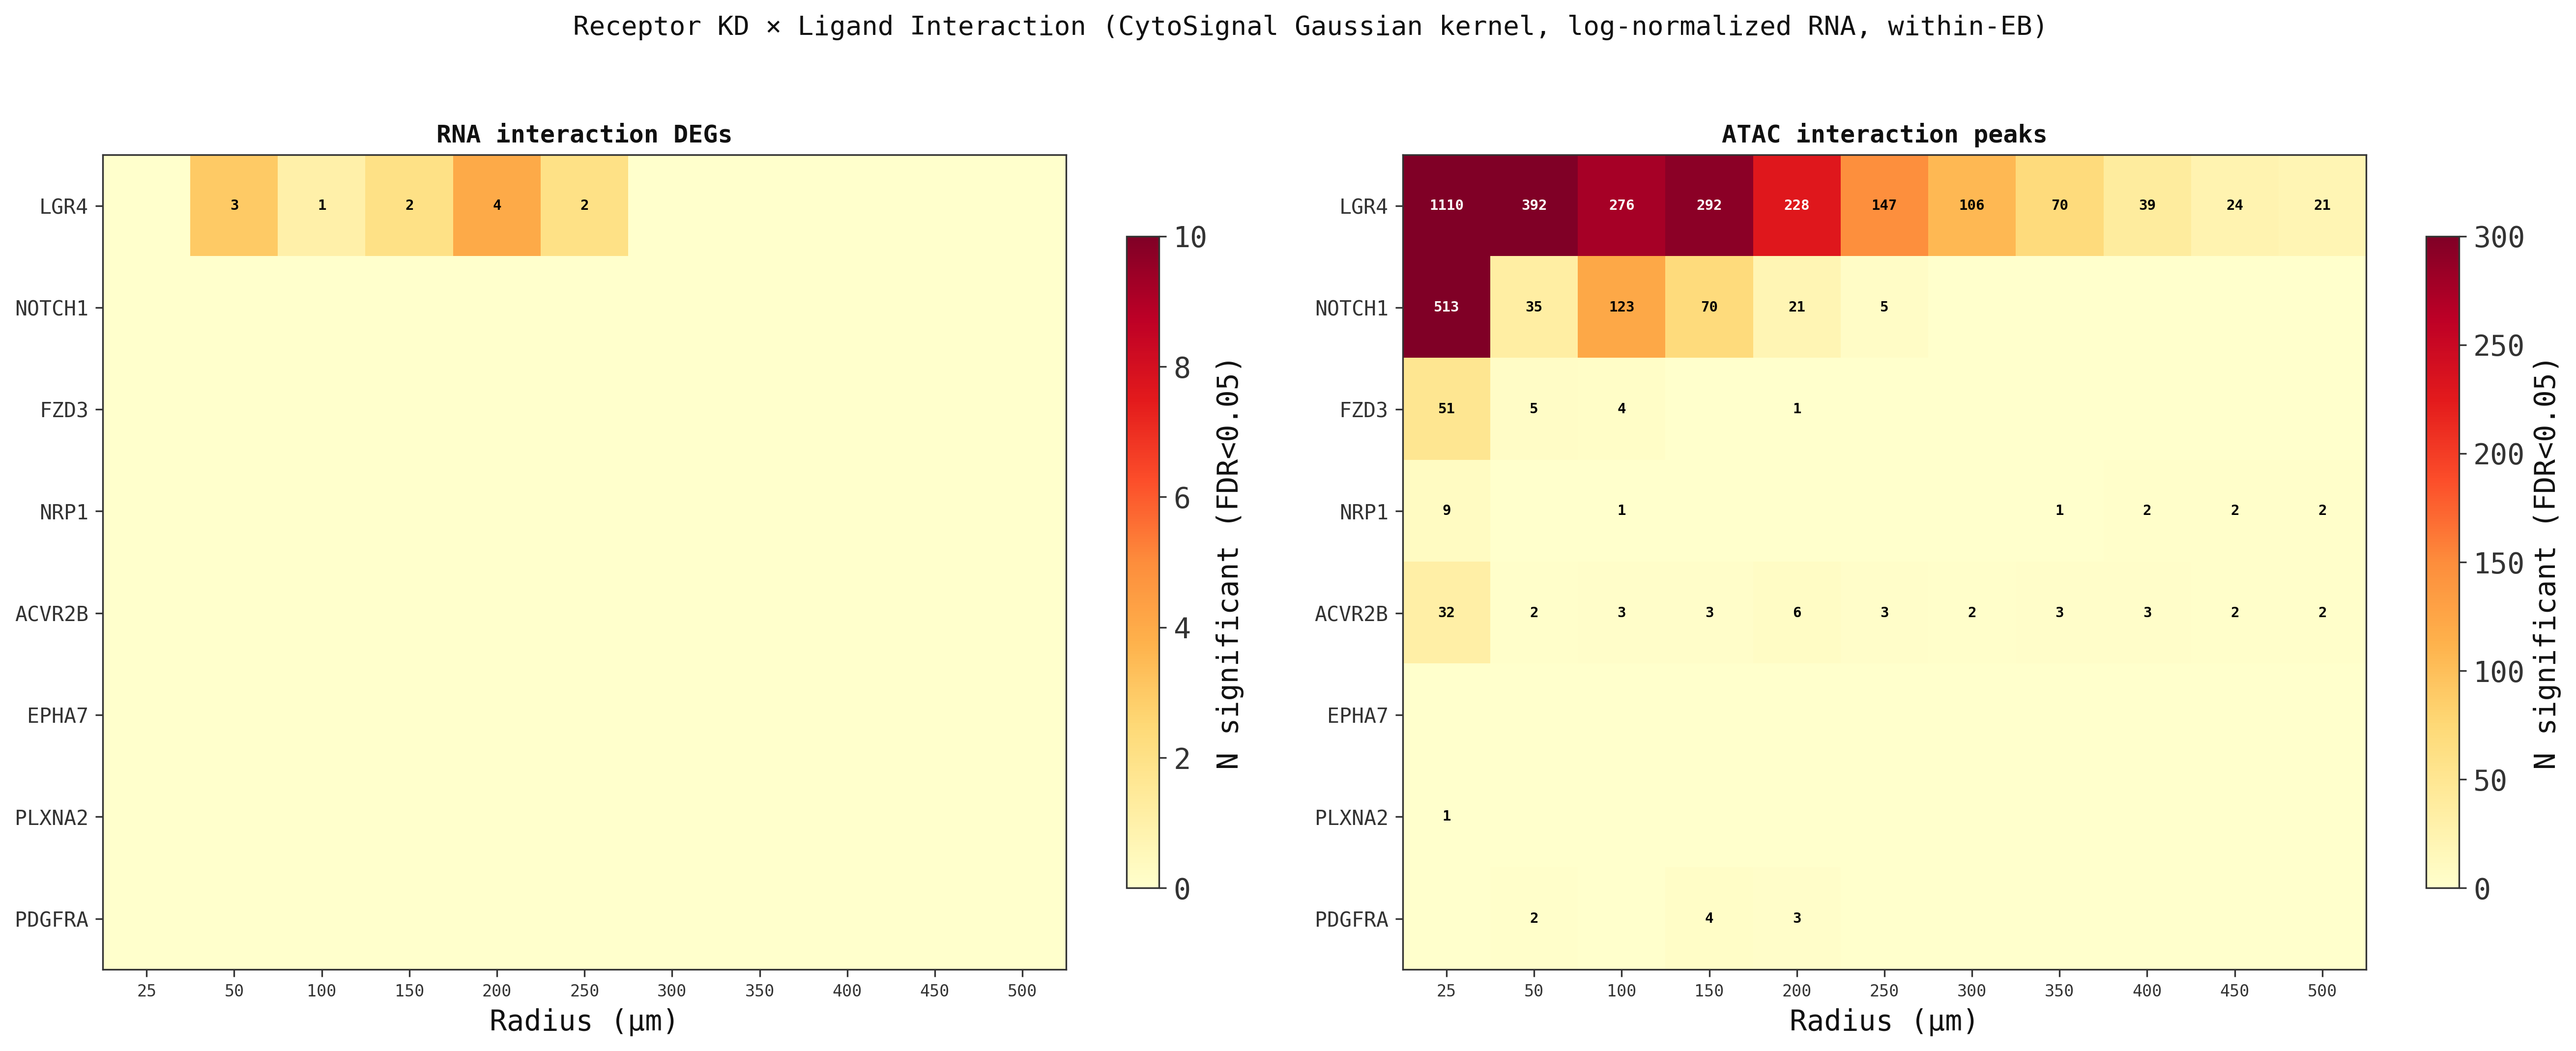

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax_idx, (col, title) in enumerate([('rna_interaction', 'RNA interaction DEGs'),
                                        ('atac_interaction', 'ATAC interaction peaks')]):
    ax = axes[ax_idx]
    matrix = np.zeros((len(RECEPTORS_ORDER), len(ALL_RADII)))
    for i, receptor in enumerate(RECEPTORS_ORDER):
        for j, radius in enumerate(ALL_RADII):
            row = res_full_df[(res_full_df['receptor'] == receptor) & (res_full_df['radius'] == radius)]
            if len(row) > 0:
                matrix[i, j] = row.iloc[0][col]

    vmax = 300 if col == 'atac_interaction' else 10
    matrix_display = np.clip(matrix, 0, vmax)
    im = ax.imshow(matrix_display, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, label='N significant (FDR<0.05)', shrink=0.8)

    for i in range(len(RECEPTORS_ORDER)):
        for j in range(len(ALL_RADII)):
            val = int(matrix[i, j])
            if val > 0:
                color = 'white' if matrix_display[i, j] > vmax * 0.6 else 'black'
                ax.text(j, i, str(val), ha='center', va='center', fontsize=7, color=color, fontweight='bold')

    ax.set_xticks(range(len(ALL_RADII)))
    ax.set_xticklabels([f'{r}' for r in ALL_RADII], fontsize=8)
    ax.set_xlabel('Radius (µm)')
    ax.set_yticks(range(len(RECEPTORS_ORDER)))
    ax.set_yticklabels(RECEPTORS_ORDER, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Receptor KD × Ligand Interaction (CytoSignal Gaussian kernel, log-normalized RNA, within-EB)',
            fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'interaction_radius_heatmap_cytosignal.png'), dpi=200, bbox_inches='tight')
plt.show()


## 6. Coefficient line plots (all receptors)

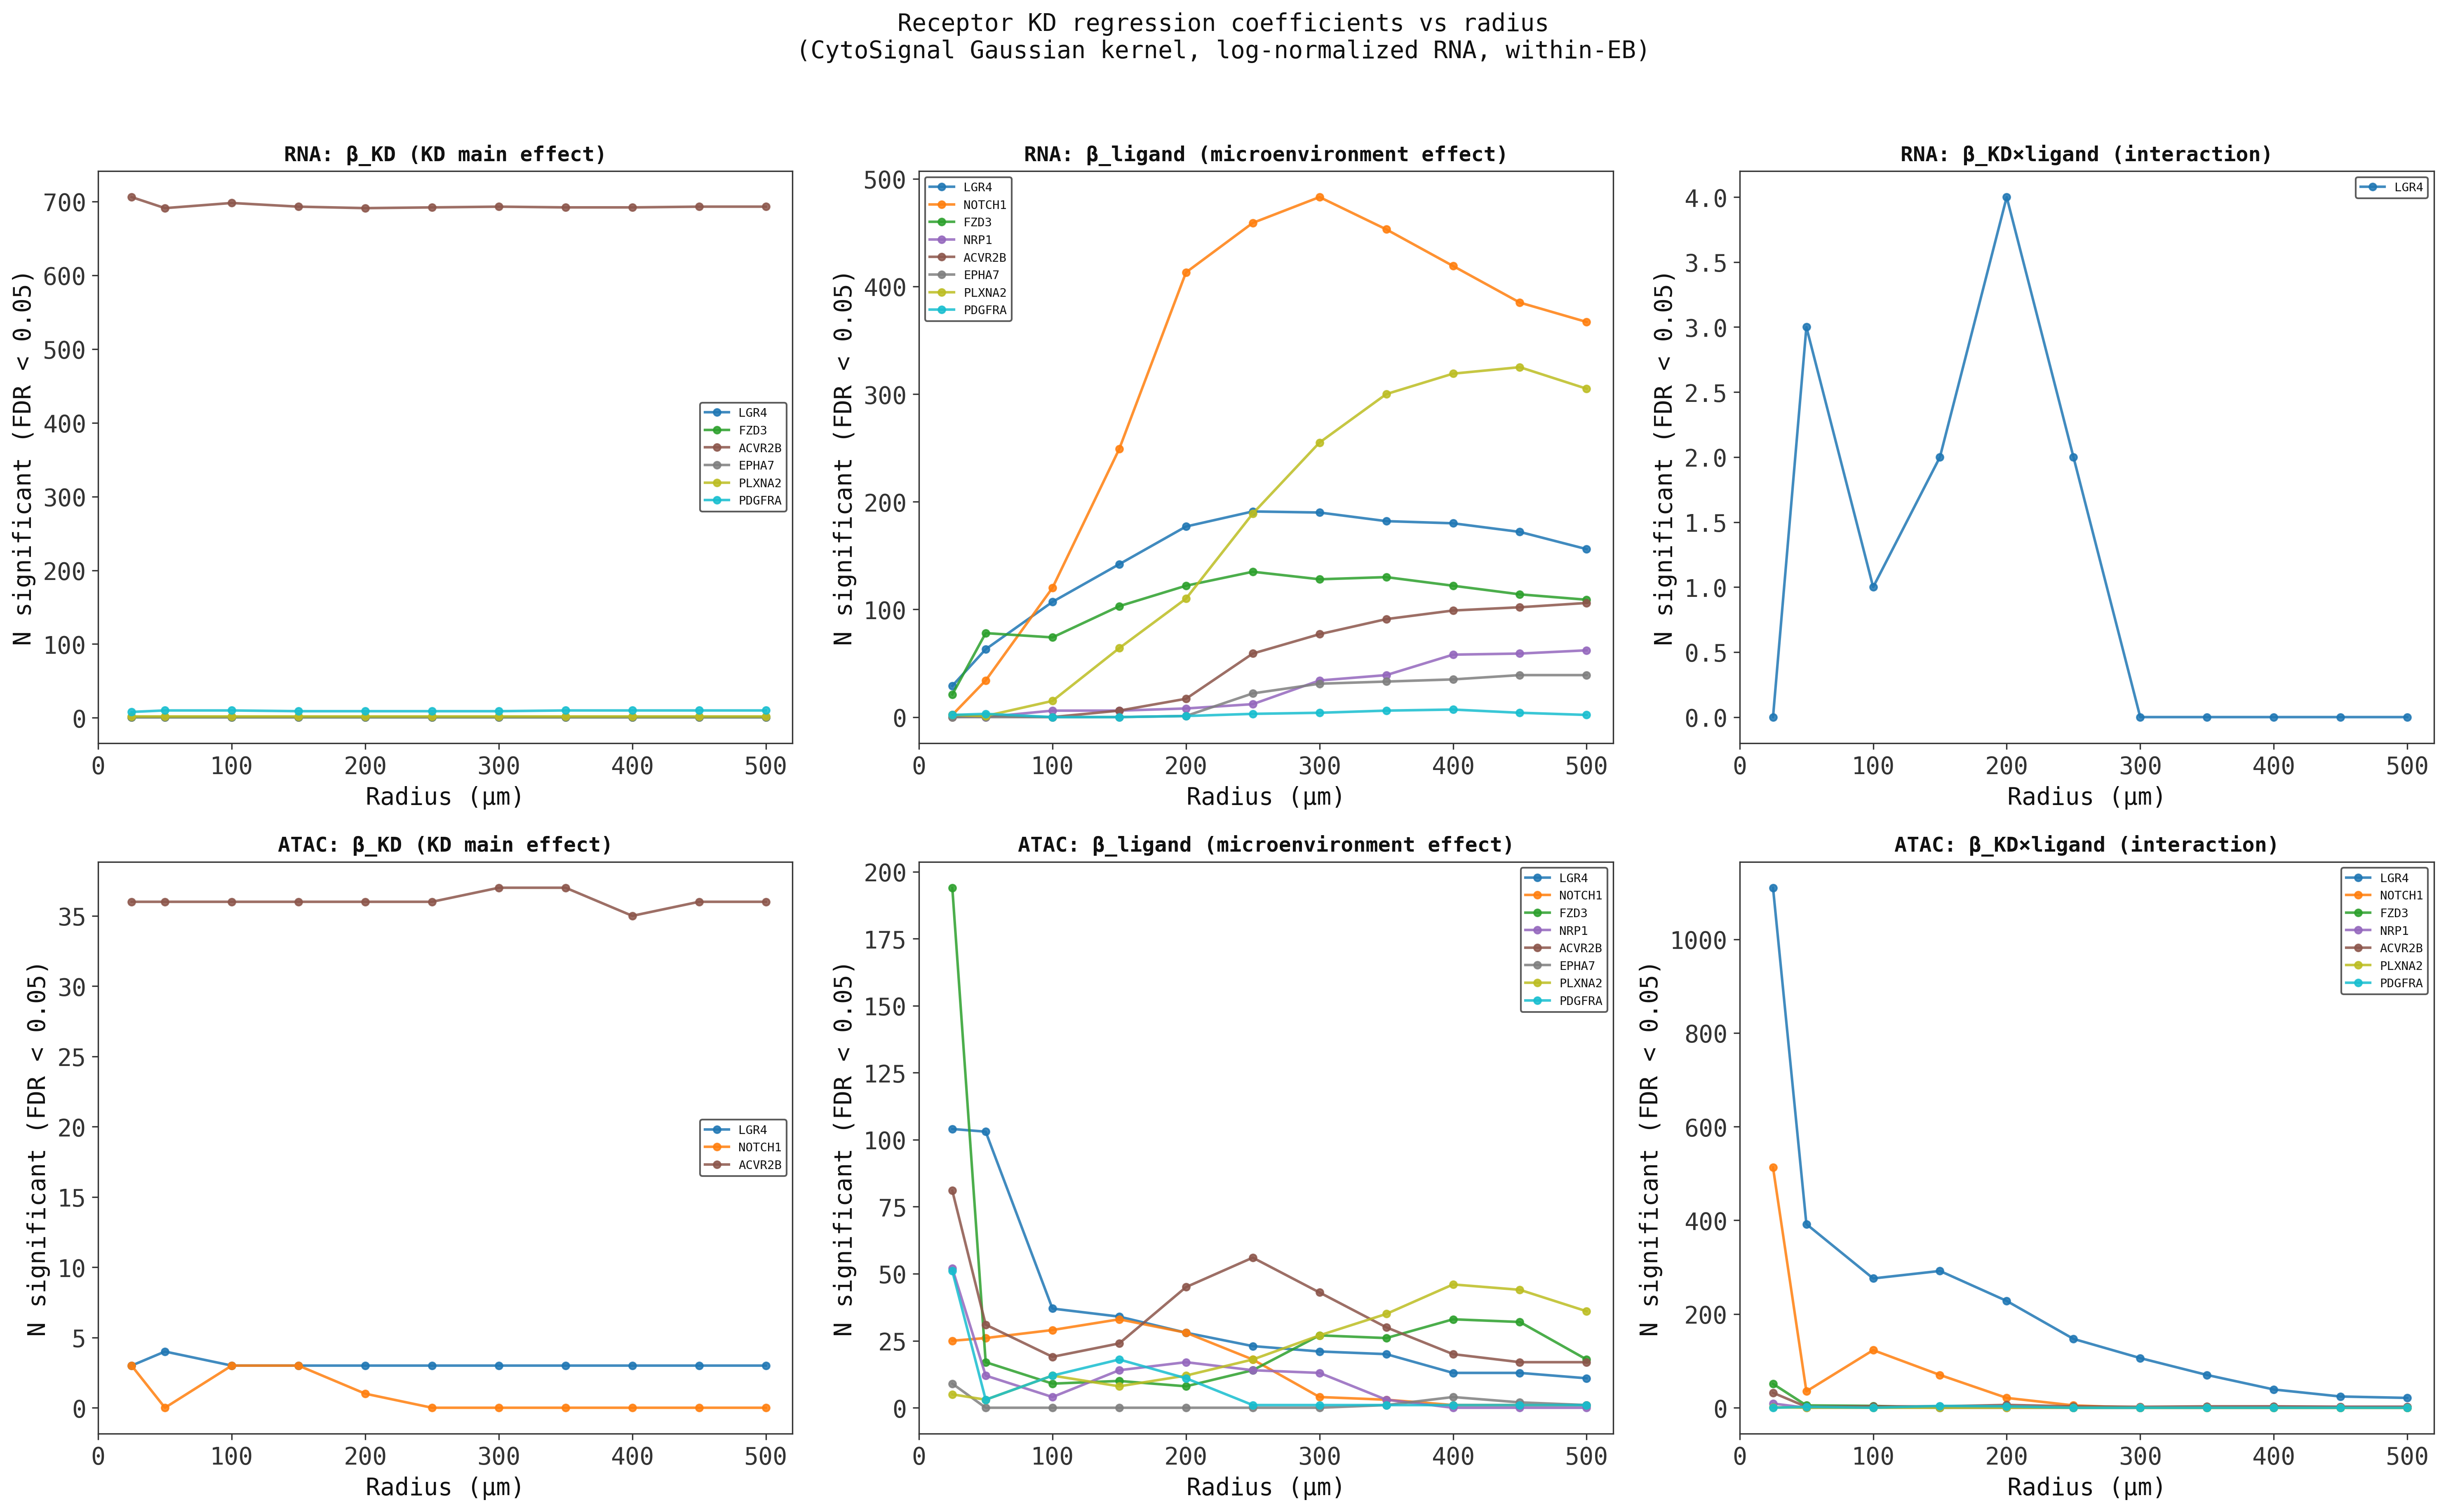

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
colors_map = dict(zip(RECEPTORS_ORDER, plt.cm.tab10(np.linspace(0, 1, len(RECEPTORS_ORDER)))))

titles = [
    ('rna_KD',          'RNA: β_KD (KD main effect)'),
    ('rna_ligand',      'RNA: β_ligand (microenvironment effect)'),
    ('rna_interaction', 'RNA: β_KD×ligand (interaction)'),
    ('atac_KD',         'ATAC: β_KD (KD main effect)'),
    ('atac_ligand',     'ATAC: β_ligand (microenvironment effect)'),
    ('atac_interaction','ATAC: β_KD×ligand (interaction)'),
]

for ax_idx, (col, title) in enumerate(titles):
    ax = axes[ax_idx // 3, ax_idx % 3]
    for receptor in RECEPTORS_ORDER:
        sub = res_full_df[res_full_df['receptor'] == receptor].sort_values('radius')
        if len(sub) == 0: continue
        vals = sub[col].values
        if max(vals) > 0:
            ax.plot(sub['radius'], vals, 'o-', color=colors_map[receptor],
                   label=receptor, linewidth=1.5, markersize=4, alpha=0.85)
    ax.set_xlabel('Radius (µm)')
    ax.set_ylabel('N significant (FDR < 0.05)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='best')
    ax.set_xlim(0, 520)

plt.suptitle('Receptor KD regression coefficients vs radius\n(CytoSignal Gaussian kernel, log-normalized RNA, within-EB)',
            fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'interaction_lineplots_all_coefficients.png'), dpi=200, bbox_inches='tight')
plt.show()


## 7. Coefficient line plots (rescaled, dominant lines removed)

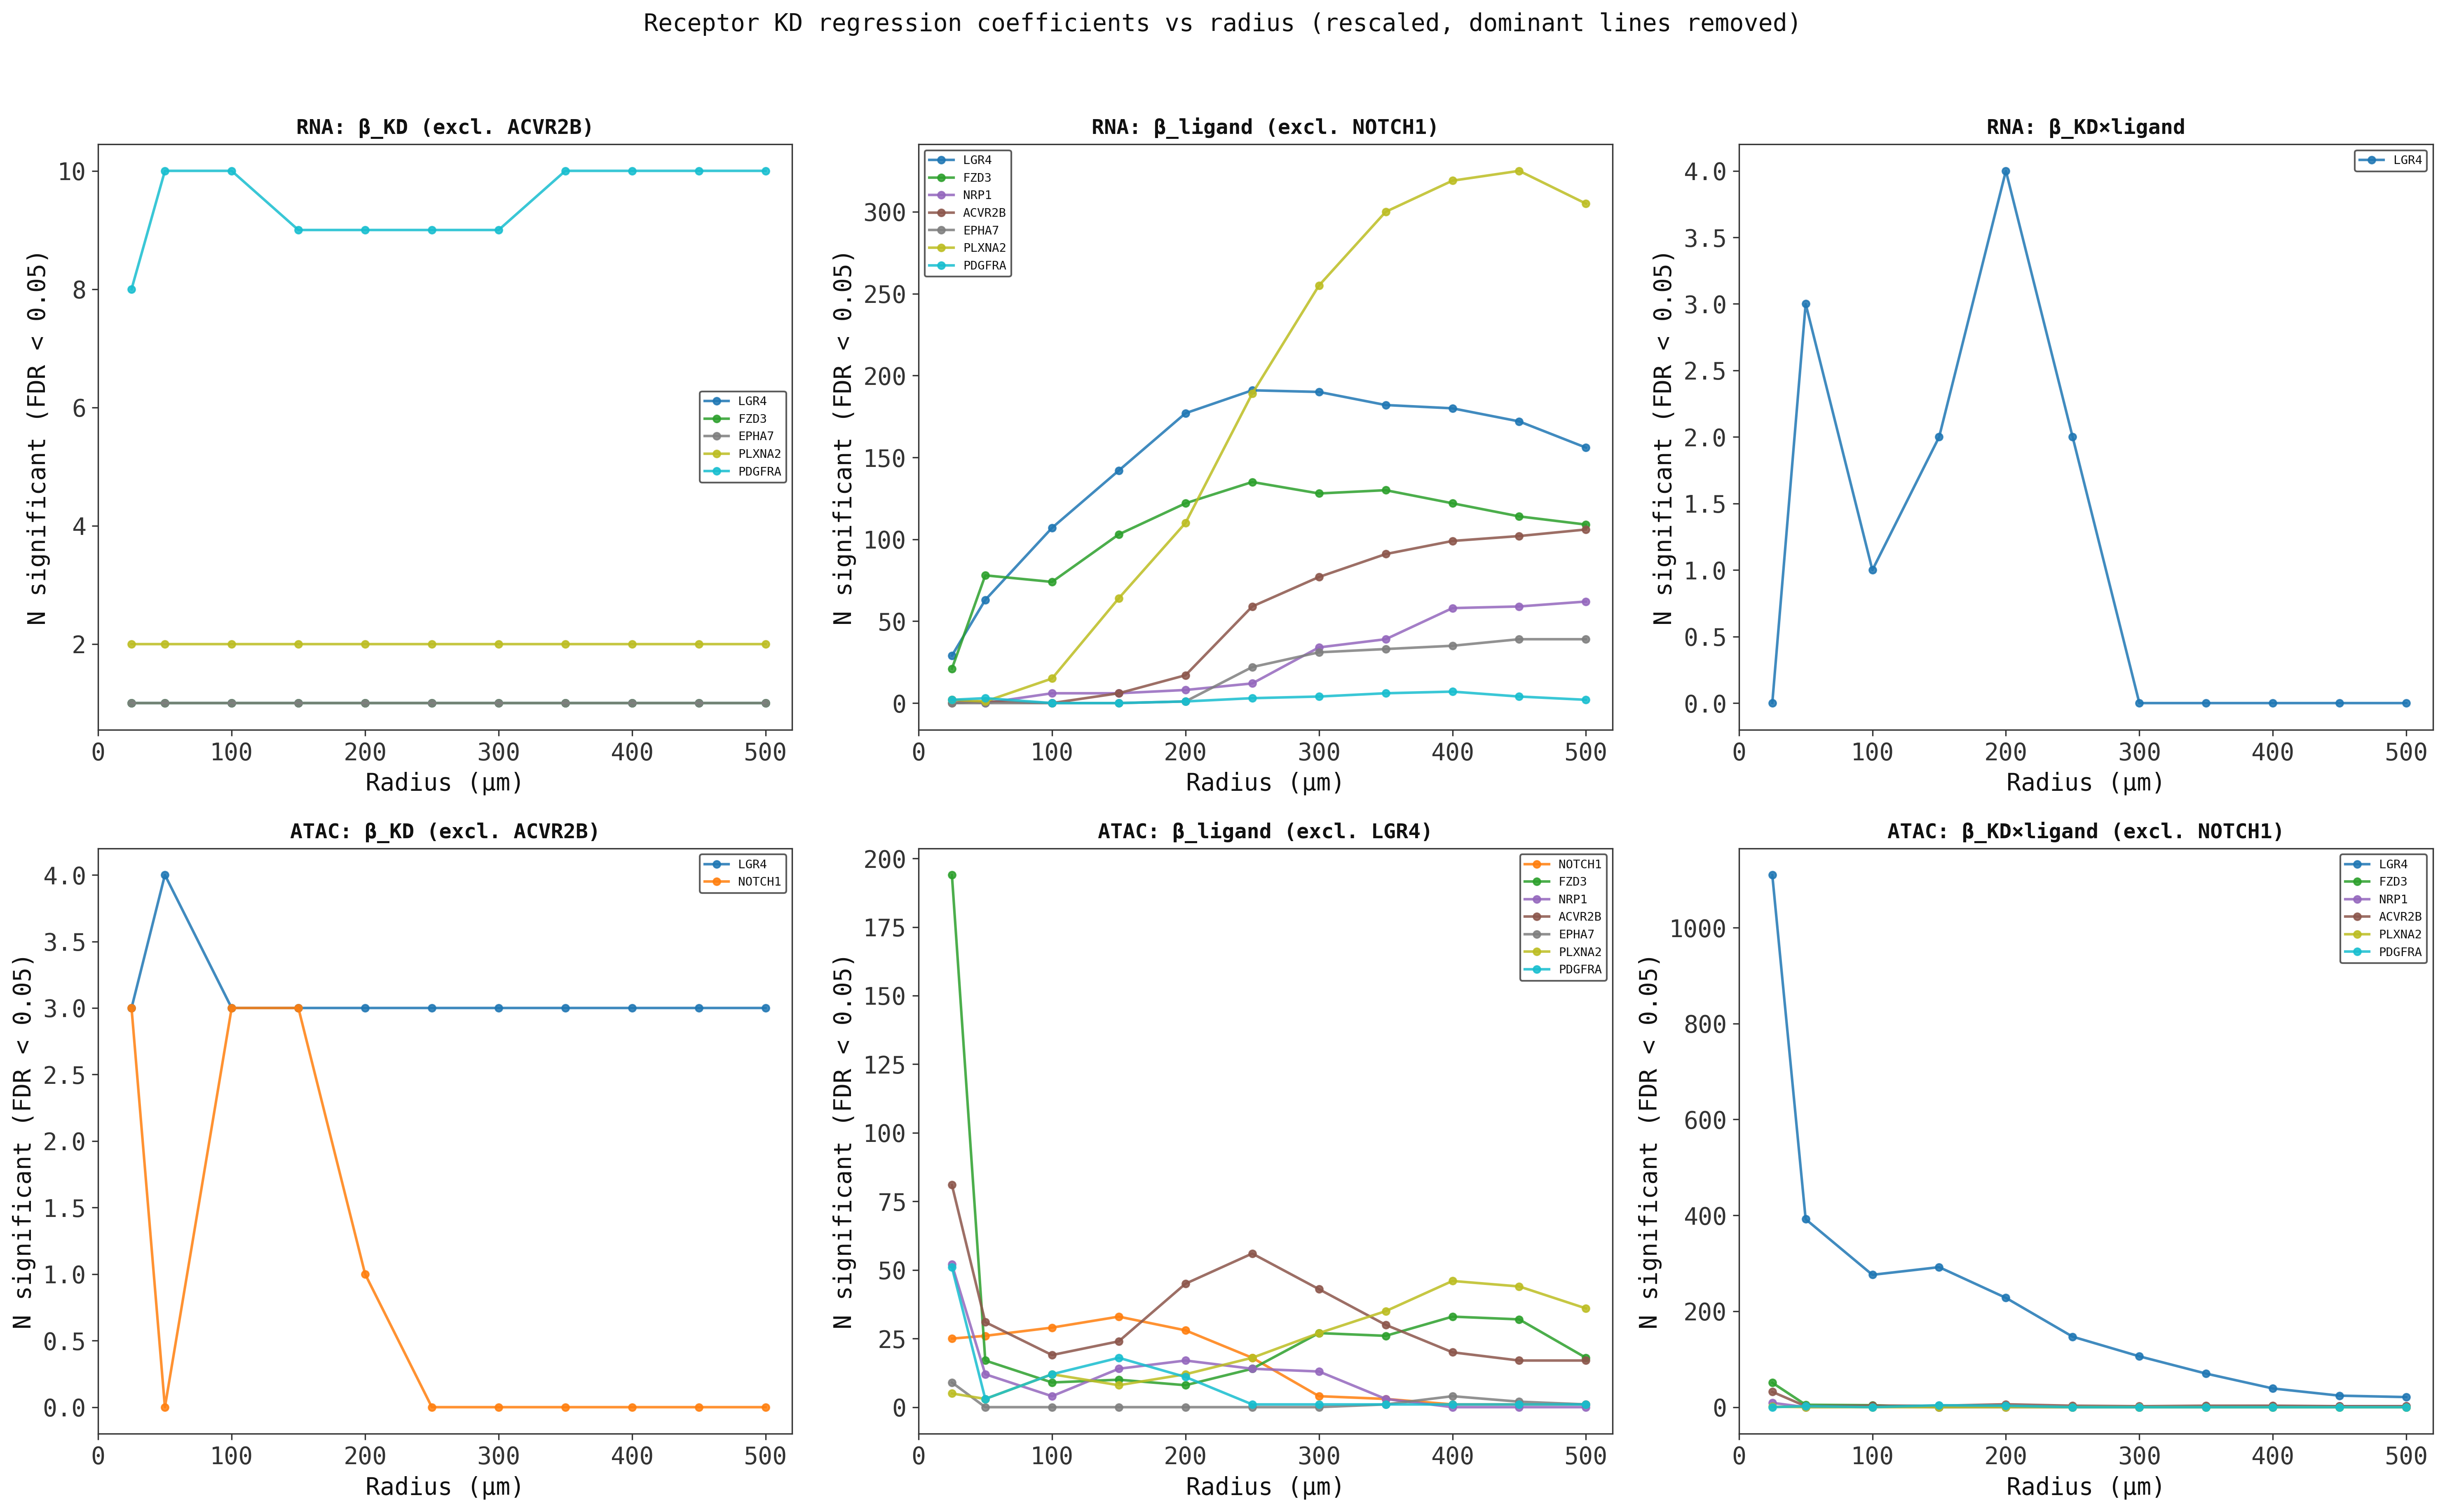

In [9]:
exclude = {
    'rna_KD': ['ACVR2B'], 'rna_ligand': ['NOTCH1'], 'rna_interaction': [],
    'atac_KD': ['ACVR2B'], 'atac_ligand': ['LGR4'], 'atac_interaction': ['NOTCH1'],
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
titles_rescaled = [
    ('rna_KD',          'RNA: β_KD (excl. ACVR2B)'),
    ('rna_ligand',      'RNA: β_ligand (excl. NOTCH1)'),
    ('rna_interaction', 'RNA: β_KD×ligand'),
    ('atac_KD',         'ATAC: β_KD (excl. ACVR2B)'),
    ('atac_ligand',     'ATAC: β_ligand (excl. LGR4)'),
    ('atac_interaction','ATAC: β_KD×ligand (excl. NOTCH1)'),
]

for ax_idx, (col, title) in enumerate(titles_rescaled):
    ax = axes[ax_idx // 3, ax_idx % 3]
    for receptor in RECEPTORS_ORDER:
        if receptor in exclude[col]: continue
        sub = res_full_df[res_full_df['receptor'] == receptor].sort_values('radius')
        if len(sub) == 0: continue
        vals = sub[col].values
        if max(vals) > 0:
            ax.plot(sub['radius'], vals, 'o-', color=colors_map[receptor],
                   label=receptor, linewidth=1.5, markersize=4, alpha=0.85)
    ax.set_xlabel('Radius (µm)')
    ax.set_ylabel('N significant (FDR < 0.05)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='best')
    ax.set_xlim(0, 520)

plt.suptitle('Receptor KD regression coefficients vs radius (rescaled, dominant lines removed)',
            fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'interaction_lineplots_rescaled.png'), dpi=200, bbox_inches='tight')
plt.show()


## 8. TE interaction heatmap

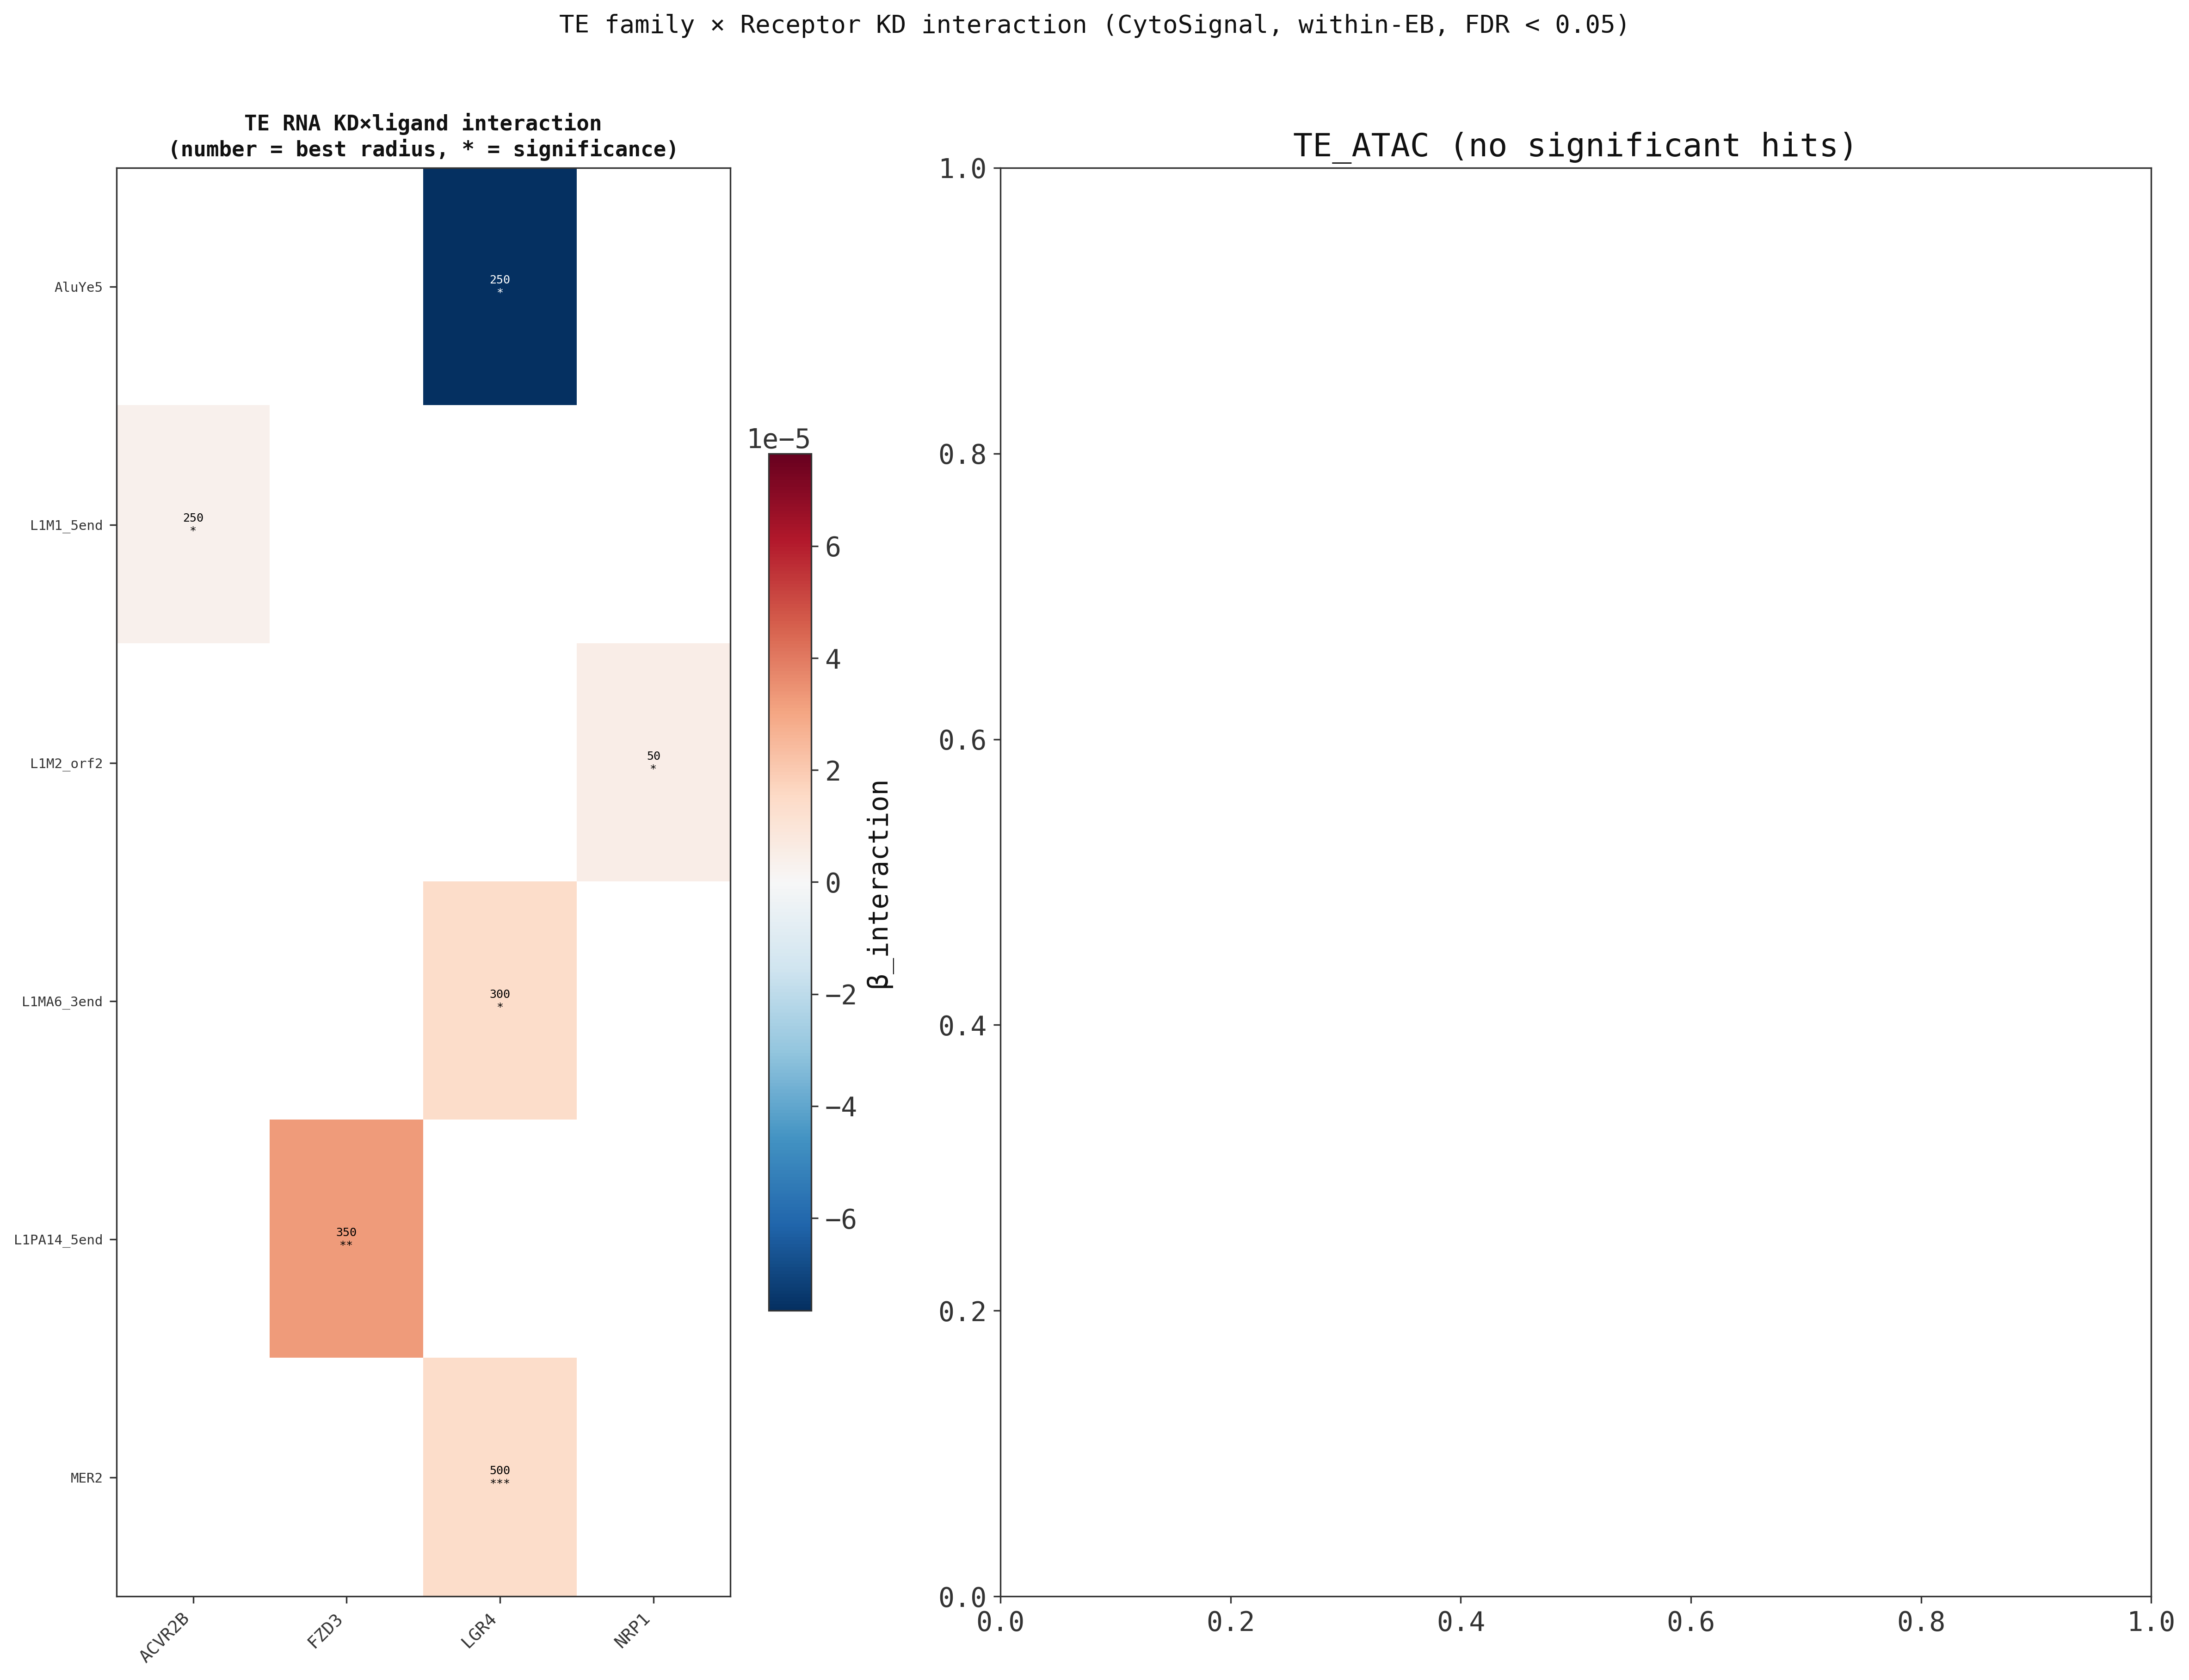

In [10]:
if len(te_hits_df) > 0:
    sig_hits = te_hits_df[te_hits_df['fdr'] < 0.05].copy()
    best_hits = sig_hits.sort_values('fdr').drop_duplicates(subset=['receptor', 'te_name', 'modality'], keep='first')

    fig, axes = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1.5]})

    for ax_idx, modality in enumerate(['TE_RNA', 'TE_ATAC']):
        ax = axes[ax_idx]
        mod_hits = best_hits[best_hits['modality'] == modality].copy()
        if len(mod_hits) == 0:
            ax.set_title(f'{modality} (no significant hits)')
            continue

        te_names_list = sorted(mod_hits['te_name'].unique())
        receptors_list = sorted(mod_hits['receptor'].unique())

        matrix = np.full((len(te_names_list), len(receptors_list)), np.nan)
        fdr_matrix = np.full((len(te_names_list), len(receptors_list)), 1.0)
        radius_matrix = np.full((len(te_names_list), len(receptors_list)), np.nan)

        for _, row in mod_hits.iterrows():
            i = te_names_list.index(row['te_name'])
            j = receptors_list.index(row['receptor'])
            matrix[i, j] = row['beta_int']
            fdr_matrix[i, j] = row['fdr']
            radius_matrix[i, j] = row['radius']

        max_abs = np.nanmax(np.abs(matrix)) if np.any(~np.isnan(matrix)) else 1
        im = ax.imshow(matrix, cmap='RdBu_r', aspect='auto', vmin=-max_abs, vmax=max_abs)
        plt.colorbar(im, ax=ax, label='β_interaction', shrink=0.6)

        for i in range(len(te_names_list)):
            for j in range(len(receptors_list)):
                if not np.isnan(matrix[i, j]):
                    r = int(radius_matrix[i, j])
                    stars = '***' if fdr_matrix[i, j] < 0.001 else ('**' if fdr_matrix[i, j] < 0.01 else '*')
                    color = 'white' if abs(matrix[i, j]) > max_abs * 0.5 else 'black'
                    ax.text(j, i, f'{r}\n{stars}', ha='center', va='center', fontsize=6, color=color)

        ax.set_xticks(range(len(receptors_list)))
        ax.set_xticklabels(receptors_list, fontsize=9, rotation=45, ha='right')
        ax.set_yticks(range(len(te_names_list)))
        ax.set_yticklabels(te_names_list, fontsize=7)
        ax.set_title(f'{modality.replace("_", " ")} KD×ligand interaction\n(number = best radius, * = significance)',
                    fontsize=11, fontweight='bold')

    plt.suptitle('TE family × Receptor KD interaction (CytoSignal, within-EB, FDR < 0.05)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'TE_interaction_heatmap_named.png'), dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("No significant TE interactions found.")


## 9. TE interaction line plots

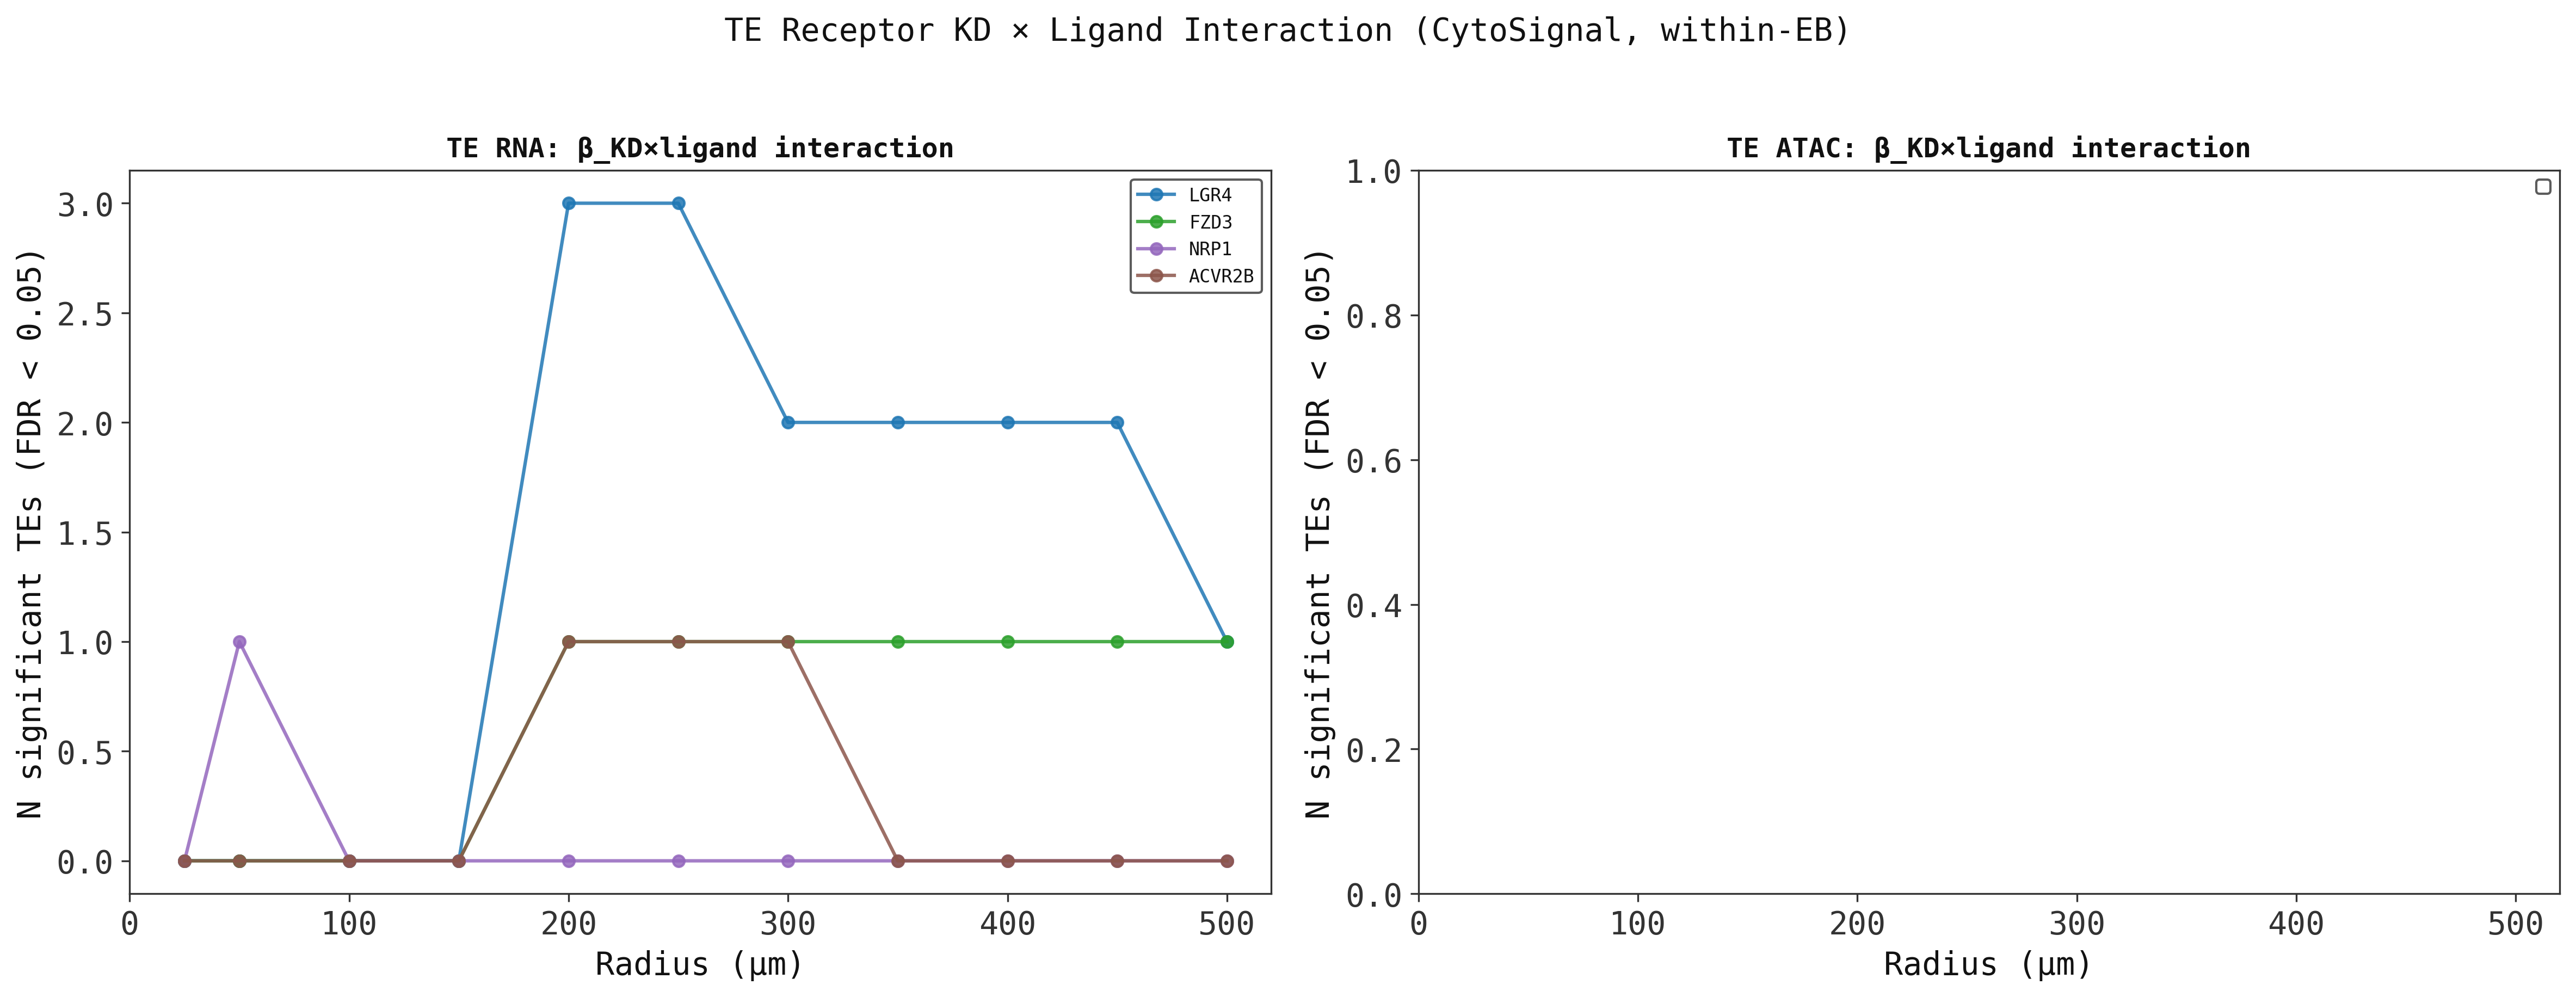

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (col, title) in enumerate([
    ('te_rna_interaction',  'TE RNA: β_KD×ligand interaction'),
    ('te_atac_interaction', 'TE ATAC: β_KD×ligand interaction')
]):
    ax = axes[ax_idx]
    for receptor in RECEPTORS_ORDER:
        sub = res_full_df[res_full_df['receptor'] == receptor].sort_values('radius')
        if len(sub) == 0: continue
        vals = sub[col].values
        if max(vals) > 0:
            ax.plot(sub['radius'], vals, 'o-', color=colors_map[receptor],
                   label=receptor, linewidth=1.5, markersize=5, alpha=0.85)
    ax.set_xlabel('Radius (µm)')
    ax.set_ylabel('N significant TEs (FDR < 0.05)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 520)

plt.suptitle('TE Receptor KD × Ligand Interaction (CytoSignal, within-EB)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'TE_interaction_lineplots.png'), dpi=200, bbox_inches='tight')
plt.show()


## 10. Save results

In [12]:
with pd.ExcelWriter(os.path.join(OUTPUT_DIR, 'receptor_interaction_results.xlsx'), engine='openpyxl') as writer:
    # Rename columns for Excel
    summary_excel = res_full_df.rename(columns={
        'receptor': 'Receptor', 'radius': 'Radius',
        'rna_KD': 'RNA_KD', 'rna_ligand': 'RNA_ligand', 'rna_interaction': 'RNA_interaction',
        'atac_KD': 'ATAC_KD', 'atac_ligand': 'ATAC_ligand', 'atac_interaction': 'ATAC_interaction',
        'te_rna_interaction': 'TE_RNA_interaction', 'te_atac_interaction': 'TE_ATAC_interaction',
    })
    summary_excel.to_excel(writer, sheet_name='Summary', index=False)

    for receptor in RECEPTORS_ORDER:
        if receptor not in all_receptor_results: continue
        best_radius = max(all_receptor_results[receptor].keys(),
                         key=lambda r: len(all_receptor_results[receptor][r]['rna'].query('fdr_interaction < 0.05'))
                         if len(all_receptor_results[receptor][r]['rna']) > 0 else 0)
        rna_df = all_receptor_results[receptor][best_radius]['rna']
        if len(rna_df) > 0:
            rna_out = rna_df.rename(columns={'gene': 'Gene', 'beta_KD': 'beta_KD', 'p_KD': 'p_KD',
                'fdr_KD': 'FDR_KD', 'p_ligand': 'p_ligand', 'fdr_ligand': 'FDR_ligand',
                'beta_interaction': 'beta_interaction', 'p_interaction': 'p_interaction', 'fdr_interaction': 'FDR_interaction'})
            rna_out.to_excel(writer, sheet_name=f'{receptor}_RNA', index=False)

    if len(te_hits_df) > 0:
        te_out = te_hits_df.rename(columns={
            'receptor': 'Receptor', 'te_name': 'TE_name', 'modality': 'Modality',
            'radius': 'Best_radius', 'beta_int': 'beta_interaction', 'fdr': 'FDR',
        })
        te_out.to_excel(writer, sheet_name='TE_interactions', index=False)

print(f"Results saved to {OUTPUT_DIR}/receptor_interaction_results.xlsx")
print(f"All figures saved to {OUTPUT_DIR}/")


Results saved to output/receptor_interaction_results.xlsx
All figures saved to output/
